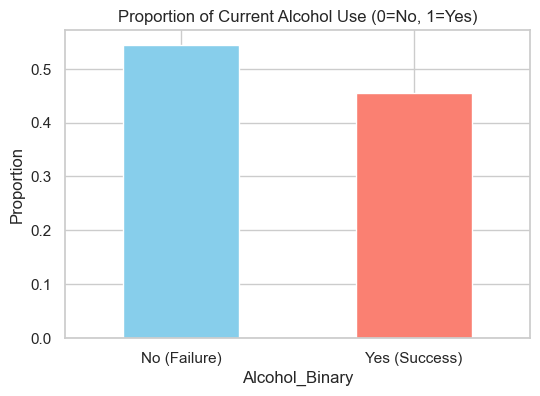

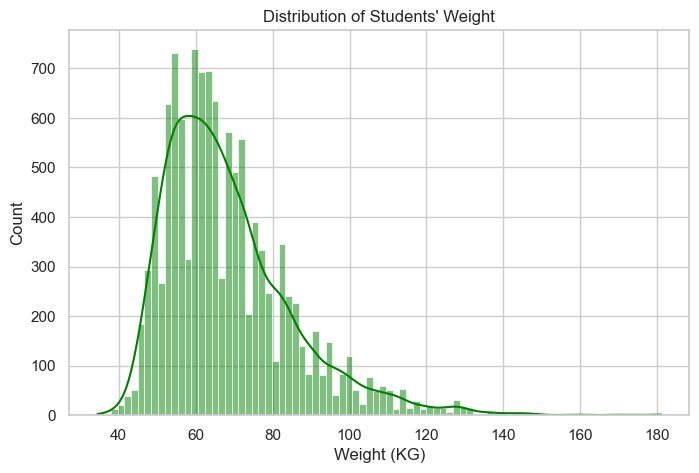

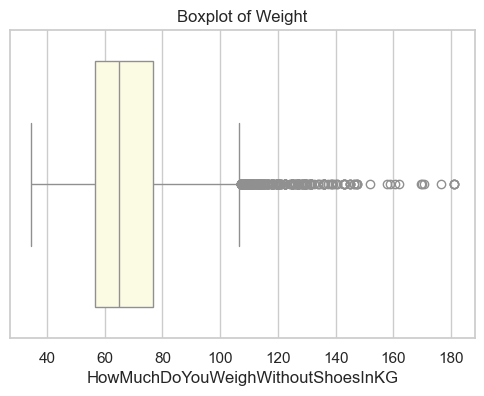

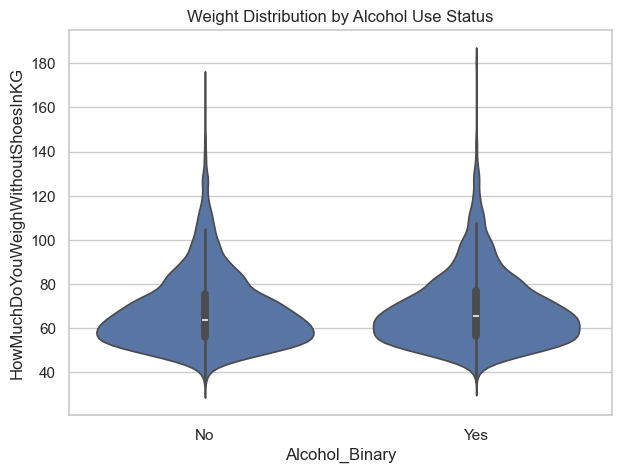

       HowMuchDoYouWeighWithoutShoesInKG
count                       11843.000000
mean                           68.426069
std                            16.904515
min                            34.470000
25%                            56.700000
50%                            64.860000
75%                            76.660000
max                           180.990000


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 讀取處理後的資料
# 路徑同樣使用 '../' 跳出 notebooks 資料夾
df = pd.read_csv('../data/processed/yrbs_recoded.csv')

# 設定繪圖風格
sns.set_theme(style="whitegrid")

# --- A. 行為變數 EDA：CurrentAlcoholUse ---

# [圖表 1] 二元化後的長條圖 (Bar Chart)
plt.figure(figsize=(6, 4))
df['Alcohol_Binary'].value_counts(normalize=True).plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Proportion of Current Alcohol Use (0=No, 1=Yes)')
plt.xticks([0, 1], ['No (Failure)', 'Yes (Success)'], rotation=0)
plt.ylabel('Proportion')
plt.savefig('../outputs/figures/alcohol_bar_chart.png') # 記得存檔 [cite: 160]
plt.show()

# (在此處新增 Markdown 儲存格，寫下對飲酒比例的初步觀察)

# --- B. 連續變數 EDA：Weight (KG) ---

# [圖表 2] 直方圖 (Histogram) - 觀察分配型態
plt.figure(figsize=(8, 5))
sns.histplot(df['HowMuchDoYouWeighWithoutShoesInKG'], kde=True, color='green')
plt.title('Distribution of Students\' Weight')
plt.xlabel('Weight (KG)')
plt.savefig('../outputs/figures/weight_histogram.png')
plt.show()

# [圖表 3] 盒鬚圖 (Boxplot) - 檢查離群值 [cite: 89, 90]
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['HowMuchDoYouWeighWithoutShoesInKG'], color='lightyellow')
plt.title('Boxplot of Weight')
plt.savefig('../outputs/figures/weight_boxplot.png')
plt.show()

# [圖表 4] 自選 EDA：依飲酒習慣分組的體重比較 
plt.figure(figsize=(7, 5))
sns.violinplot(x='Alcohol_Binary', y='HowMuchDoYouWeighWithoutShoesInKG', data=df)
plt.title('Weight Distribution by Alcohol Use Status')
plt.xticks([0, 1], ['No', 'Yes'])
plt.savefig('../outputs/figures/weight_by_alcohol_violin.png')
plt.show()

# --- C. 數值摘要統計 ---
# 計算平均數、中位數、標準差等 [cite: 85, 86, 87]
eda_summary = df[['HowMuchDoYouWeighWithoutShoesInKG']].describe()
print(eda_summary)
eda_summary.to_csv('../outputs/tables/eda_summary_table.csv') # 存成表格 [cite: 160]